In [ ]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import pickle
import sys
sys.path.append('..\\src')

In [2]:
broiler_path = "..\\data\\broiler" # Path to the folder that contains broiler images
local_path = "..\\data\\local" # Path to the folder that contains local images


In [3]:
from data_loader import *
images, labels = load_images(local_path, broiler_path, size=(64, 64))
            

In [4]:
print(images.shape)
print(labels.shape)
print(np.sum(labels==0))
print(np.sum(labels==1))
print(images.min())
print(images.max())

(343, 64, 64, 3)
(343,)
176
167
0
255


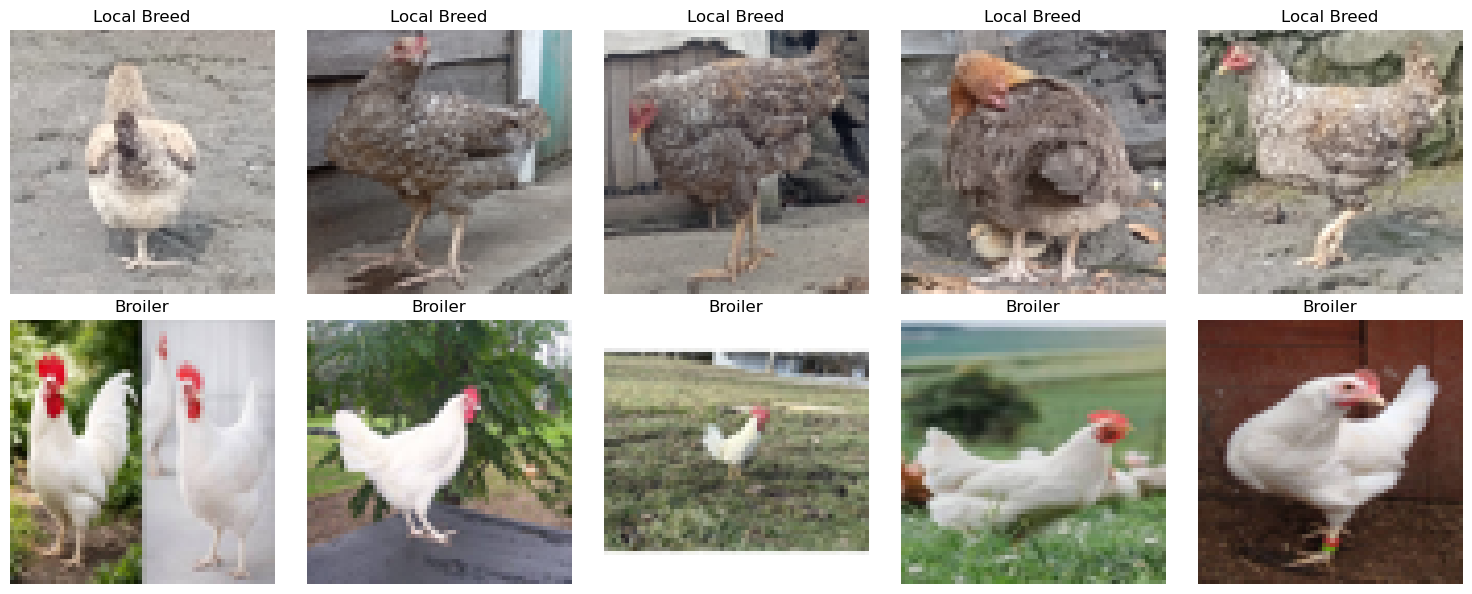

In [5]:
local_ind = np.where(labels==0)[0]
broiler_ind = np.where(labels==1)[0]

local_samples = np.random.choice(local_ind, 5, replace=False)
broiler_samples = np.random.choice(broiler_ind, 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(local_samples):
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title("Local Breed")
    axes[0, i].axis('off')

for i, idx in enumerate(broiler_samples):
    axes[1, i].imshow(images[idx])
    axes[1, i].set_title("Broiler")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [18]:
from preprocessing import (flatten_images, split_data, normalize_data)

X, y = flatten_images(images, labels)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, random_state=42)
X_train, X_val, X_test, mean, std = normalize_data(X_train, X_val, X_test)

In [19]:
print(X_train.shape, X_val.shape, X_test.shape)

(240, 12288) (51, 12288) (52, 12288)


In [21]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(240, 1)
(51, 1)
(52, 1)


In [ ]:
from train import *

layers_dims = [12288, 64, 32, 16, 1]
parameters = initialize_parameters(layers_dims)

parameters, costs = train(X_train.T, y_train.T, layers_dims, learning_rate=0.001, iterations=5000, print_cost=True)


Cost after iteration 0: 1.7888450626945274
Cost after iteration 100: 0.3452227206593075
Cost after iteration 200: 0.2274565496342668
Cost after iteration 300: 0.16044631830160003
Cost after iteration 400: 0.11948005376296304
Cost after iteration 500: 0.09211132516740678
Cost after iteration 600: 0.07196906398882712
Cost after iteration 700: 0.05755684945768162
Cost after iteration 800: 0.046902517022274326
Cost after iteration 900: 0.03891502040608484
Cost after iteration 1000: 0.03259585445390502
Cost after iteration 1100: 0.02775179895594549
Cost after iteration 1200: 0.024045189730637243
Cost after iteration 1300: 0.021130410903865023
Cost after iteration 1400: 0.018789191384460096
Cost after iteration 1500: 0.01686558814916221
Cost after iteration 1600: 0.015247599146858195
Cost after iteration 1700: 0.013882123976551225
Cost after iteration 1800: 0.012697858900284138
Cost after iteration 1900: 0.011668340358909813
Cost after iteration 2000: 0.010781348421023774
Cost after iteratio

In [23]:
from evaluate import *
train_preds = predict(X_train.T, parameters)
print(f'Training accuracy is : {accuracy(train_preds, y_train.T)}')

val_preds = predict(X_val.T, parameters)
print(f'Validation accuracy is : {accuracy(val_preds, y_val.T)}')

test_preds = predict(X_test.T, parameters)
print(f'Test accuracy is : {accuracy(test_preds, y_test.T)}')

Training accuracy is : 100.0
Validation accuracy is : 88.23529411764706
Test accuracy is : 90.38461538461539


In [24]:
with open('..\\models\\parameters.pkl', 'wb') as f:
    pickle.dump(parameters, f)

train_stats = {'mean': mean, 'std': std}
with open('..\\models\\train_stats.pkl', 'wb') as f:
    pickle.dump(train_stats, f)

In [26]:
from predict import *
path = 'D:\Projects\Chicken Classifier\data\local\IMG_20260605_142454~2.jpg'
result = predict(path)
print(result)

{'Label': 'Local', 'Probability': 0.0005, 'Confidence': 99.95}


In [27]:
path = 'D:\\Projects\\Chicken Classifier\\data\\broiler\\images - 2026-06-09T134943.859.jpeg'
result = predict(path)
print(result)

{'Label': 'Broiler', 'Probability': 0.9999, 'Confidence': 99.99}
